## 🧩 Substation Clustering for Multi-Root Wind Farms

This notebook demonstrates how `OptiWindNet` uses **substation clustering**(`clusterize()`) to partition multi-substation wind farms into single-root sub-fields.

### Key Motivation & Concepts

1. **Enabling Meta-Heuristics (HGS & LKH-3) for Multi-Root Farms**:
 CVRP algorithms like Hybrid Genetic Search (`hgs_cvrp`) and Lin-Kernighan-Helsgaun (`lkh3`) are single-depot solvers. They cannot solve multi-substation instances as a single global problem. `OptiWindNet` automatically uses `clusterize()` to decompose multi-root farms into single-depot sub-problems before passing them to HGS or LKH-3.

2. **Avoiding Cross-Root Rings in Ringed Topologies**:
 When optimizing a multi-substation site for a **ringed topology**with `MILPRouter(model_options=ModelOptions(topology='ringed'))`, the MILP formulation can form **cross-root rings**(rings that start at Substation A and return to Substation B). By running `clusterize()` first and optimizing each cluster independently, every ring is guaranteed to return to the *same* substation root (single-root rings).

### Load Modules & Data

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.interarraylib import S_from_G, as_normalized, G_from_S, rings_from_S
from optiwindnet.clustering import clusterize
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.api import WindFarmNetwork, MILPRouter, ModelOptions
from optiwindnet.pathfinding import PathFinder
from optiwindnet.svg import svgplot
import networkx as nx
import numpy as np

%config InlineBackend.figure_formats = ['svg']

### 1. Graphically Visualizing Substation Clusters

Let's load two multi-substation wind farm layouts (**Borssele**with 2 substations and **Hornsea One**with 3 substations) and inspect how `clusterize()` partitions their layout meshes into distinct sub-fields. `svgplot()` colors turbines by their `subtree` node attribute, so assigning each substation cluster a distinct `subtree` value makes the partition visible.

Borssele cluster sizes: [96, 77]


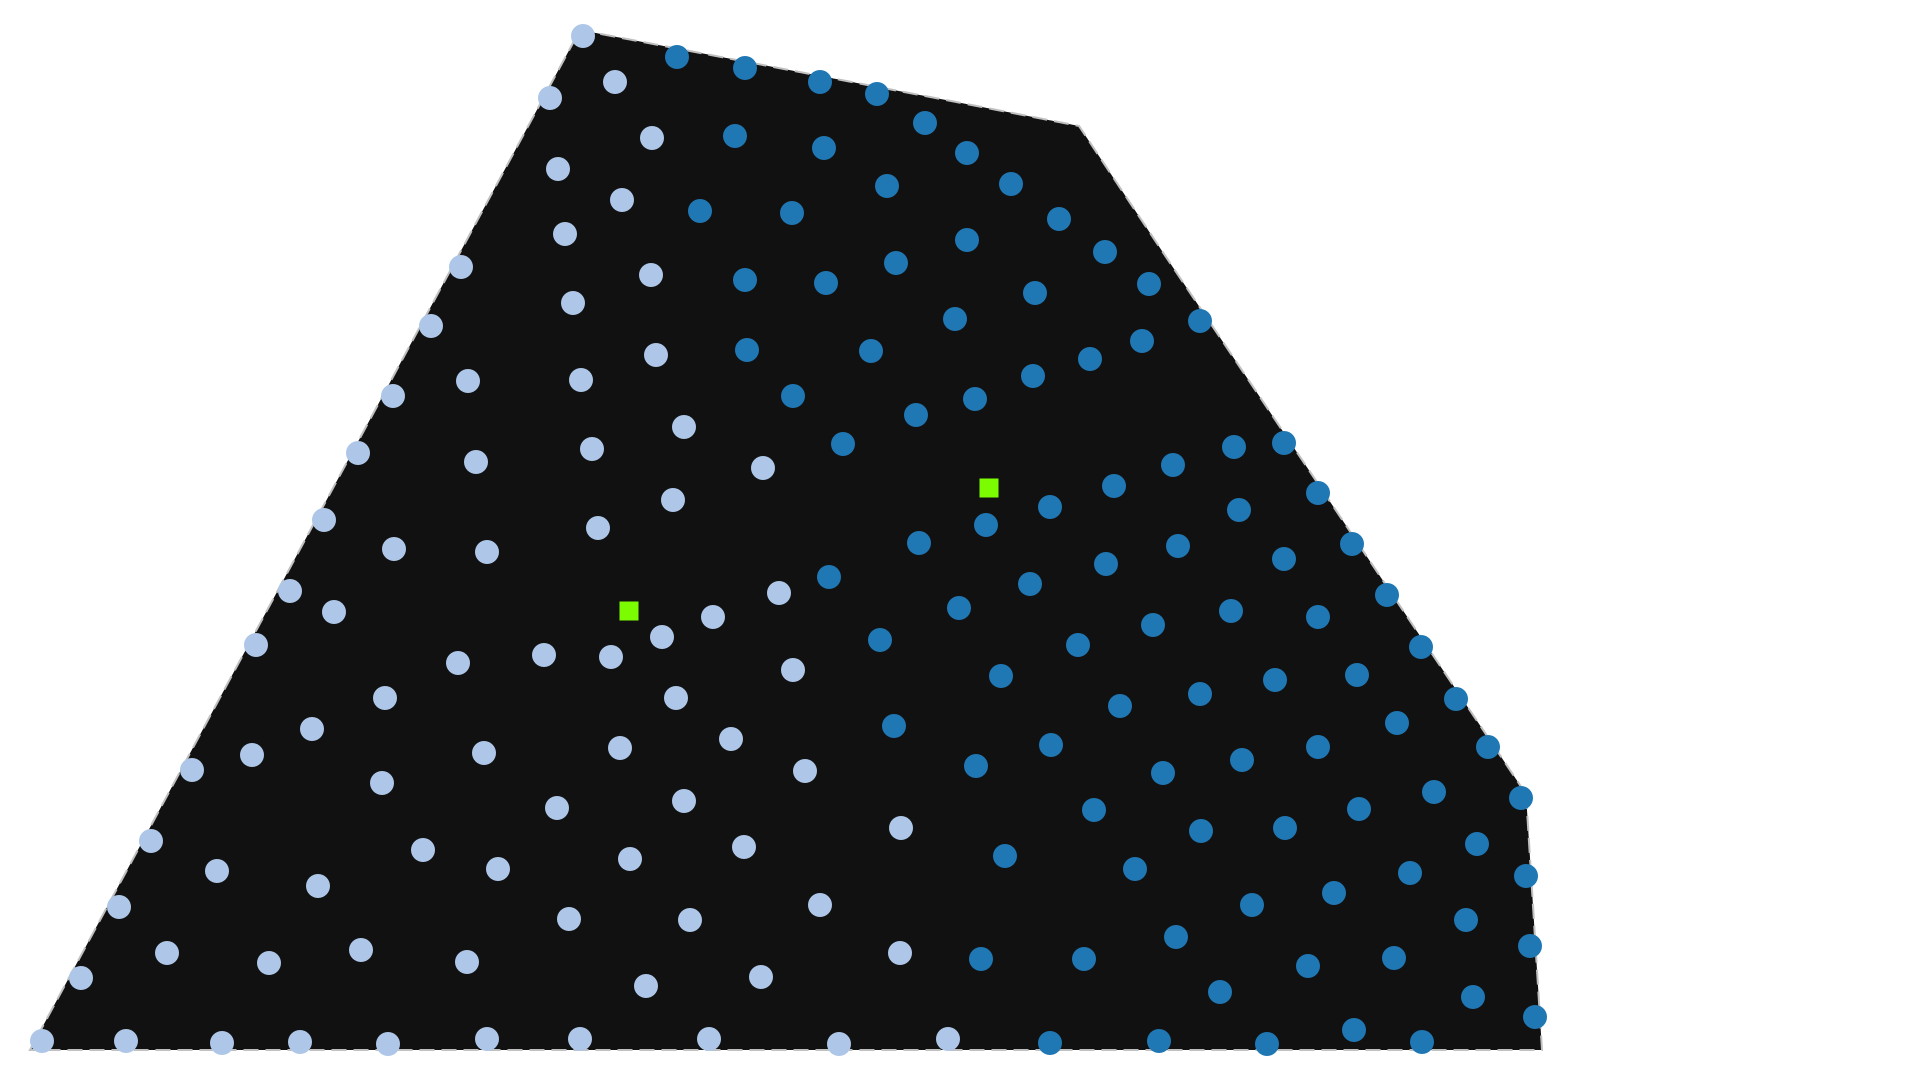

In [2]:
def color_clusters(L, clusters):
    subtree = {
        node: cluster_id for cluster_id, nodes in enumerate(clusters) for node in nodes
    }
    nx.set_node_attributes(L, subtree, name='subtree')


locations = load_repository()

# Borssele (2 substations)
L_borssele = locations.borssele
P_borssele, A_borssele = make_planar_embedding(L_borssele)
clusters_borssele = clusterize(as_normalized(A_borssele), capacity=7)

color_clusters(L_borssele, clusters_borssele)

print(f'Borssele cluster sizes: {[len(nodes) for nodes in clusters_borssele]}')
svgplot(L_borssele)

Hornsea One cluster sizes: [56, 49, 69]


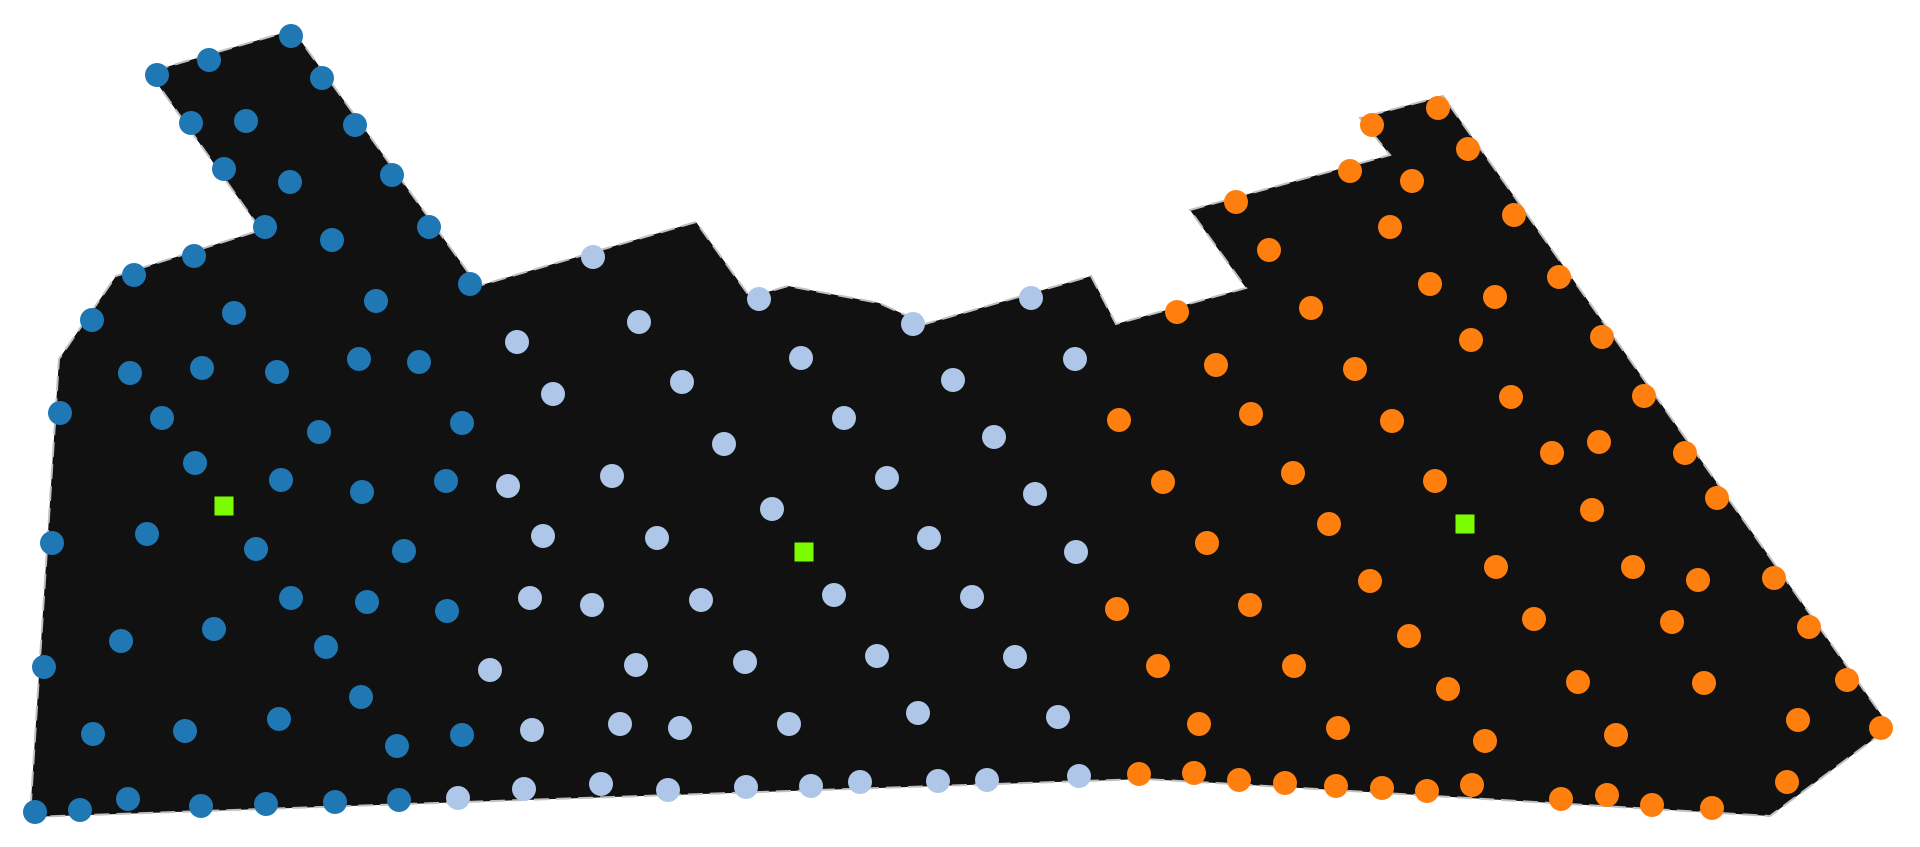

In [3]:
# Hornsea One (3 substations)
L_hornsea = locations.hornsea
P_hornsea, A_hornsea = make_planar_embedding(L_hornsea)
clusters_hornsea = clusterize(as_normalized(A_hornsea), capacity=7)

color_clusters(L_hornsea, clusters_hornsea)

print(f'Hornsea One cluster sizes: {[len(nodes) for nodes in clusters_hornsea]}')
svgplot(L_hornsea)

### 2. Multi-Root Meta-Heuristic Routing (`HGSRouter`)

Because HGS solves single-depot CVRPs, `HGSRouter` and `hgs_cvrp()` use `clusterize()` under the hood to solve multi-root instances smoothly.

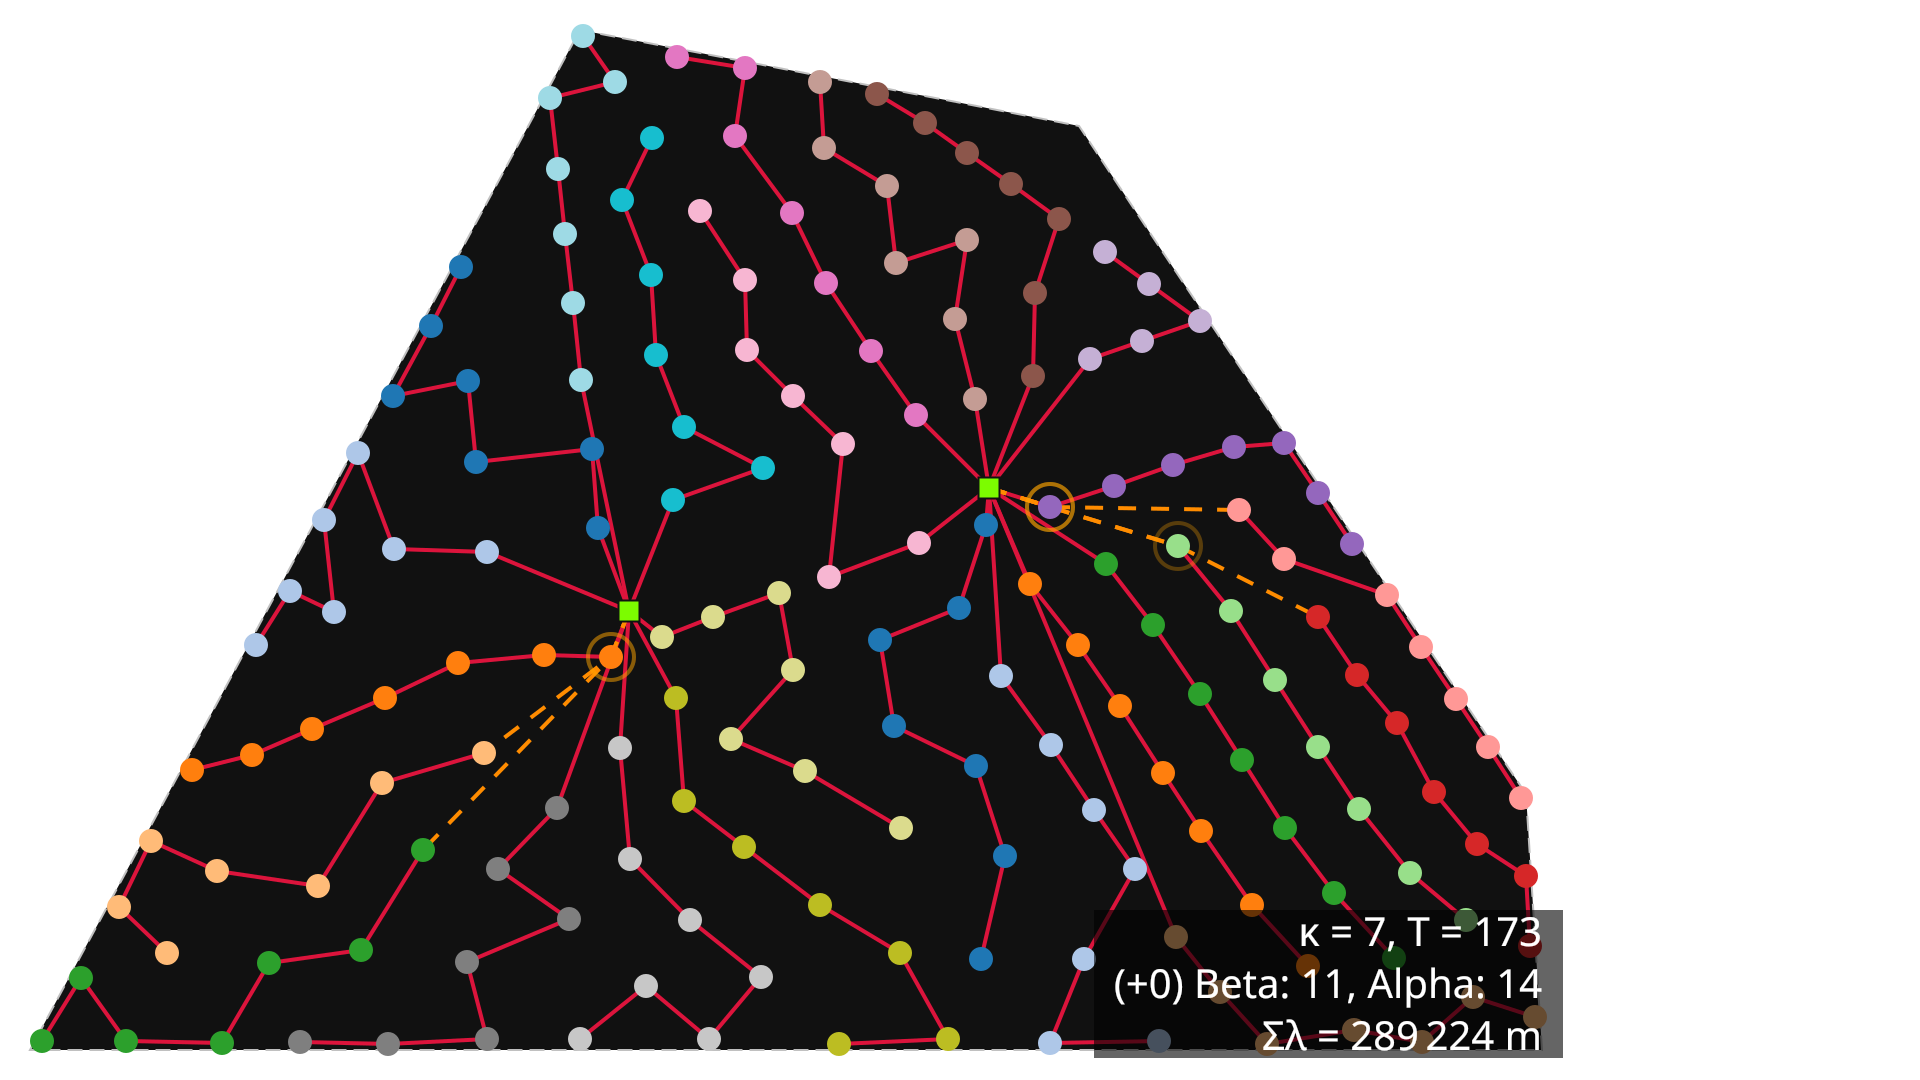

In [4]:
# HGSRouter automatically decomposes multi-root layouts via clusterize()
S_hgs = hgs_cvrp(as_normalized(A_borssele), capacity=7, time_limit=1.0)
G_hgs = G_from_S(S_hgs, A_borssele)
H_hgs = PathFinder(G_hgs, P_borssele, A_borssele).create_detours()
svgplot(H_hgs)

### 3. Preventing Cross-Root Rings in Ringed Topologies

A ringed MILP is free to use different roots at the two ends of a ring. On **Neart na Gaoithe**, the smallest packaged multi-substation site, an unrestricted capacity-4 model produces such a bridge. Both cases below use Gurobi with a 20-second limit per MILP solve. Ring endpoints are checked after routing by reconstructing the topology from `G`, because `PathFinder` may re-hook a tentative feeder.

#### Without `clusterize()`

The unrestricted routed network joins both substations in one connected component. The SVG therefore shows a ring bridging the two green substation squares.

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Roots in each routed component: [[-2, -1]]
Cross-root rings: [((-2, -1), [44, 3, 37, 10, 48, 24, 23, 43])]


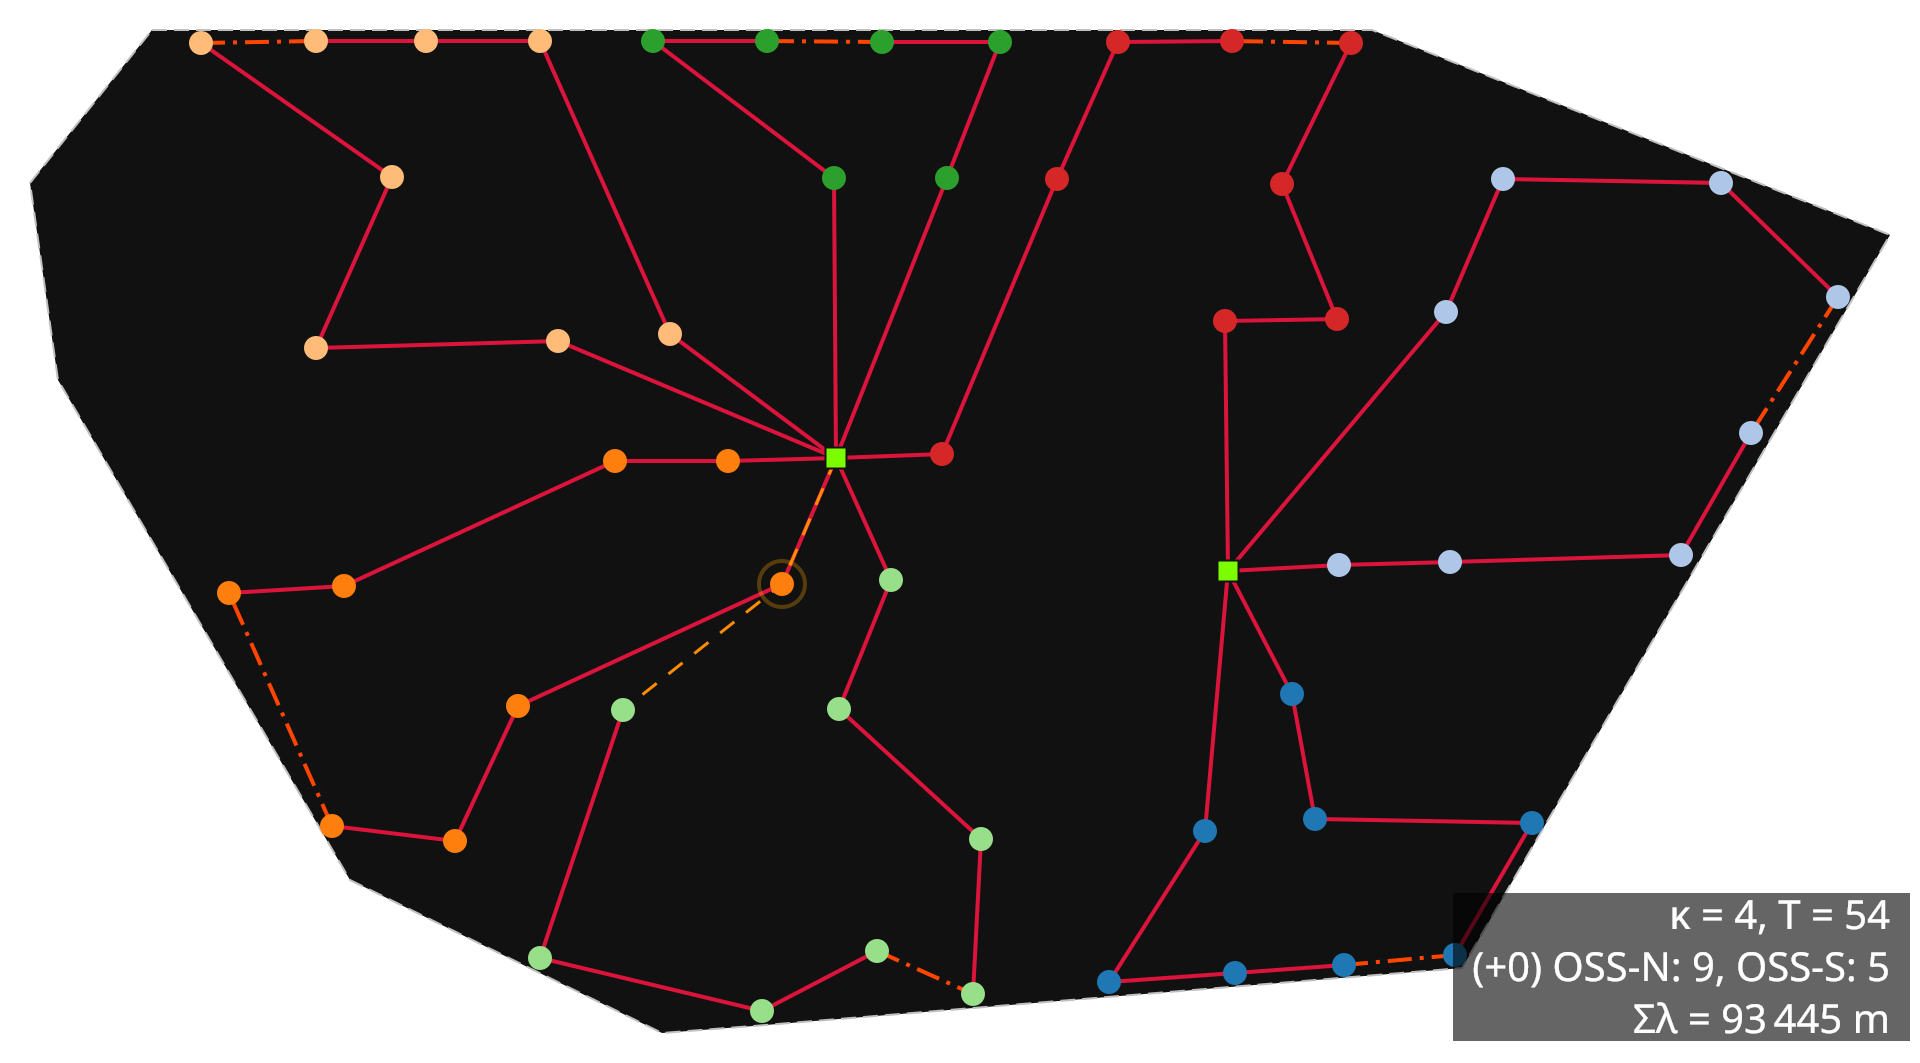

In [5]:
ring_site = WindFarmNetwork(cables=4, L=locations.neart)


def make_ringed_milp():
    return MILPRouter(
        solver_name='gurobi',
        time_limit=20,
        mip_gap=0.0,
        model_options=ModelOptions(topology='ringed'),
    )


def roots_by_component(S):
    roots = set(range(-S.graph['R'], 0))
    return [
        sorted(roots.intersection(component))
        for component in nx.connected_components(S)
        if roots.intersection(component)
    ]


ring_site.optimize(router=make_ringed_milp())
S_unclustered_routed = S_from_G(ring_site.G)
rings_unclustered = rings_from_S(S_unclustered_routed)
bridges_unclustered = [
    (roots, terminals) for roots, terminals in rings_unclustered if roots[0] != roots[1]
]

print('Roots in each routed component:', roots_by_component(S_unclustered_routed))
print('Cross-root rings:', bridges_unclustered)
svgplot(ring_site.G)

#### With `clusterize()`

`clusterize()` assigns each turbine to one substation. Each cluster is then built, optimized, and routed as a fresh single-root site. The already-routed cluster graphs are remapped and merged only for visualization, so neither the MILP nor `PathFinder` can reach the other root. This also avoids modifying the available-links graph or its `diagonals` metadata.

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Cluster sizes: [23, 31]
Roots in each routed component: [[-2], [-1]]
Cross-root rings: []


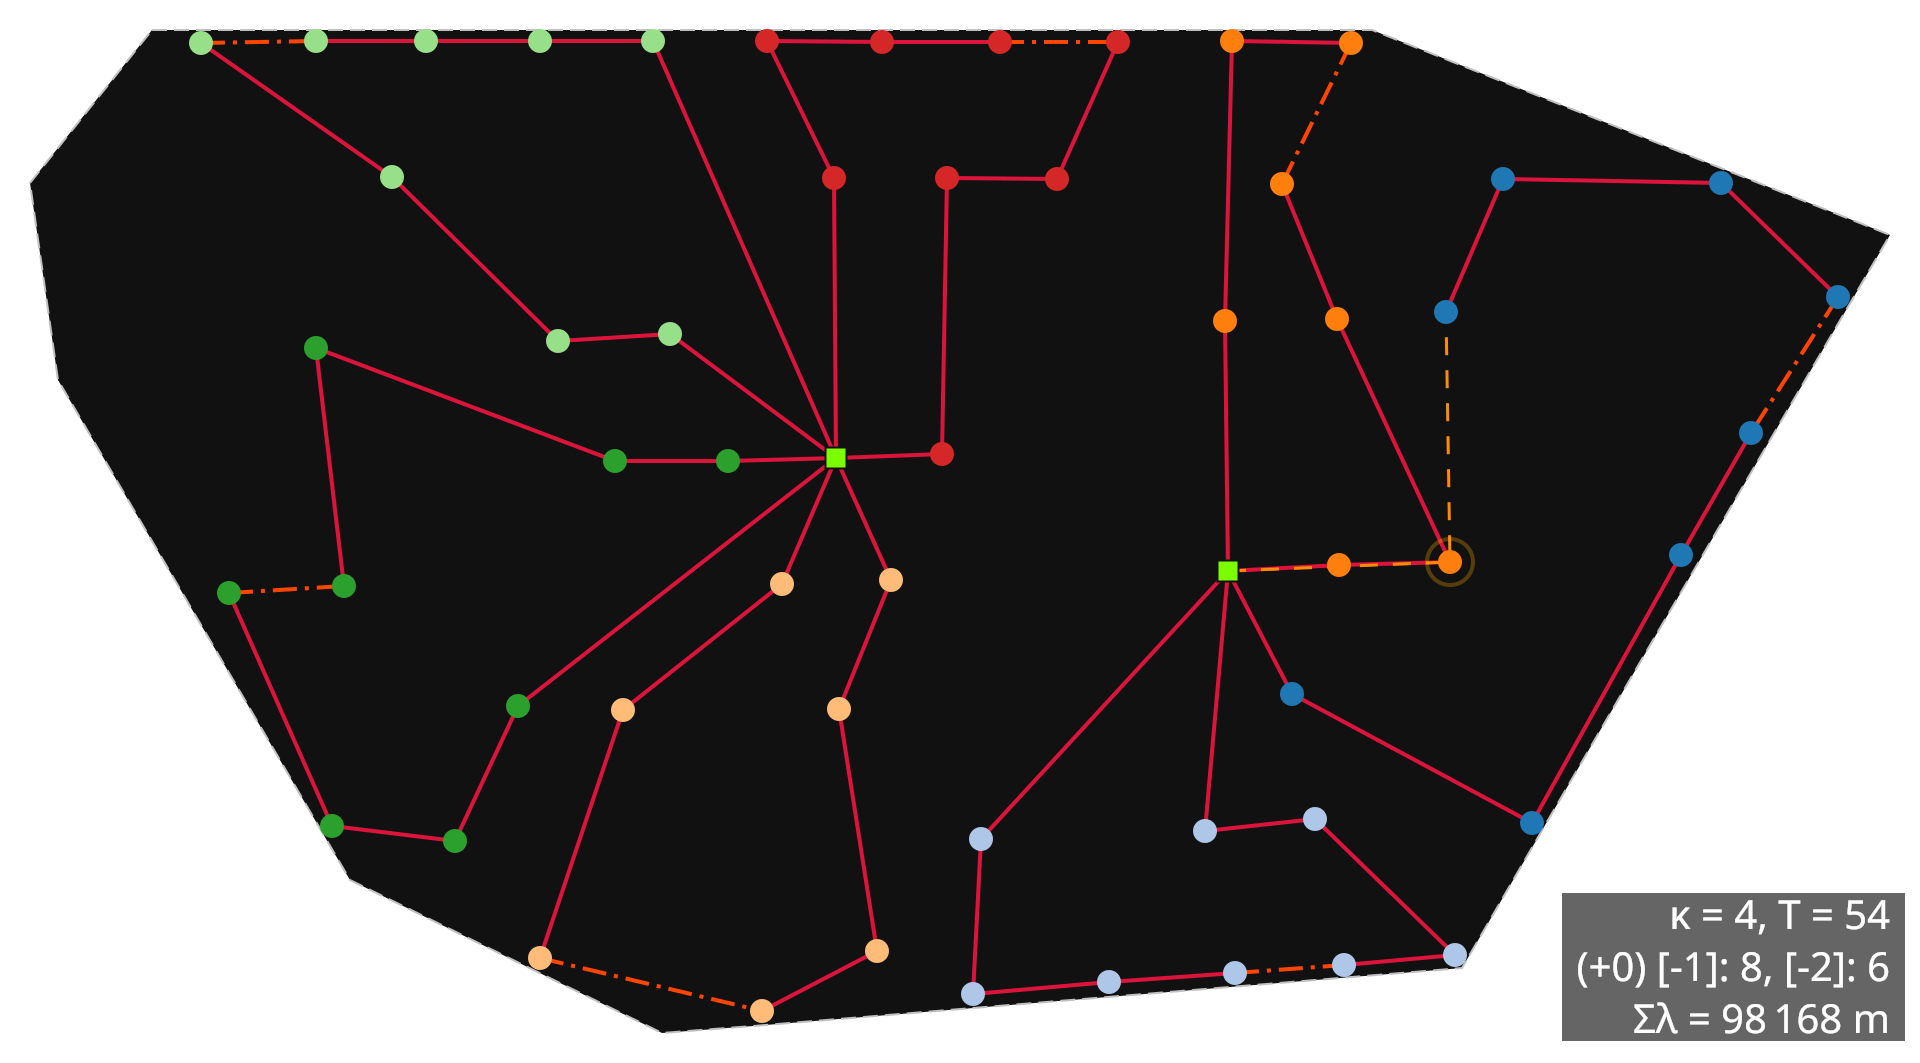

In [6]:
def make_cluster_site(site, cluster_id, cluster):
    L = site.L
    R = L.graph['R']
    VertexC = L.graph['VertexC']
    border = L.graph.get('border', np.array([], dtype=int))
    obstacles = L.graph.get('obstacles', [])
    return WindFarmNetwork(
        cables=site.cables,
        turbinesC=VertexC[sorted(cluster)],
        substationsC=VertexC[[-R + cluster_id]],
        borderC=VertexC[border],
        obstacleC_=[VertexC[obstacle] for obstacle in obstacles],
        name=f'{L.graph["name"]} — cluster {cluster_id + 1}',
    )


def node_coord(G, node):
    fnT = G.graph.get('fnT')
    coord_id = fnT[node] if fnT is not None else node
    return G.graph['VertexC'][coord_id]


def merge_cluster_routes(site, solved):
    """Merge already-routed single-root graphs without rerunning PathFinder."""
    L = site.L
    R, T, B = (L.graph[key] for key in 'RTB')
    contours = []
    detours = []
    for terminals, cluster_id, G_local in solved:
        T_local, B_local = (G_local.graph[key] for key in 'TB')
        C_local = G_local.graph.get('C', 0)
        contours.extend(
            (cluster_id, node, node_coord(G_local, node))
            for node in range(T_local + B_local, T_local + B_local + C_local)
        )
        detours.extend(
            (cluster_id, node, node_coord(G_local, node))
            for node in range(
                T_local + B_local + C_local,
                T_local + B_local + C_local + G_local.graph.get('D', 0),
            )
        )

    aux_coord = [coord for *_, coord in contours + detours]
    VertexC = L.graph['VertexC']
    merged_VertexC = np.vstack((VertexC[: T + B], *aux_coord, VertexC[-R:]))
    G = nx.Graph()
    G.graph.update(
        L.graph
        | {
            'VertexC': merged_VertexC,
            'capacity': site.cables_capacity,
            'topology': 'ringed',
            'C': len(contours),
            'D': len(detours),
            'cables': site.cables,
            'creator': 'clusterize + MILP.gurobi',
            'has_loads': True,
        }
    )
    aux_map = {
        (cluster_id, node): T + B + i
        for i, (cluster_id, node, _) in enumerate(contours + detours)
    }

    subtree_offset = 0
    for terminals, cluster_id, G_local in solved:
        mapping = {local: global_ for local, global_ in enumerate(terminals)}
        mapping[-1] = -R + cluster_id
        mapping.update(
            {
                node: global_
                for (owner, node), global_ in aux_map.items()
                if owner == cluster_id
            }
        )
        local_subtrees = {
            data['subtree']
            for node, data in G_local.nodes.items()
            if node >= 0 and 'subtree' in data
        }
        for node, data in G_local.nodes.items():
            data = data.copy()
            if 'subtree' in data:
                data['subtree'] += subtree_offset
            G.add_node(mapping[node], **data)
        G.add_edges_from(
            (mapping[u], mapping[v], data.copy())
            for u, v, data in G_local.edges(data=True)
        )
        subtree_offset += len(local_subtrees)

    G.graph['max_load'] = max(
        (data['load'] for _, _, data in G.edges(data=True)), default=0
    )
    return G


clusters_ring = clusterize(
    as_normalized(ring_site.A), capacity=ring_site.cables_capacity
)
solved_clusters = []
for cluster_id, cluster in enumerate(clusters_ring):
    cluster_site = make_cluster_site(ring_site, cluster_id, cluster)
    cluster_site.optimize(router=make_ringed_milp())
    solved_clusters.append((sorted(cluster), cluster_id, cluster_site.G))

G_clustered = merge_cluster_routes(ring_site, solved_clusters)
S_clustered_routed = S_from_G(G_clustered)
rings_clustered = rings_from_S(S_clustered_routed)
bridges_clustered = [
    (roots, terminals) for roots, terminals in rings_clustered if roots[0] != roots[1]
]

print('Cluster sizes:', [len(cluster) for cluster in clusters_ring])
print('Roots in each routed component:', roots_by_component(S_clustered_routed))
print('Cross-root rings:', bridges_clustered)
svgplot(G_clustered)

### Summary

* **Meta-heuristics**: `HGSRouter` and `LKH` rely on `clusterize()` to handle multi-substation farms.
* **Cluster visualization**: assigning the cluster index to each turbine's `subtree` attribute lets `svgplot()` display the partition directly.
* **Ringed MILP**: Neart's unrestricted capacity-4 solution bridges roots, while independently optimizing and routing each cluster guarantees single-root rings.